In [11]:
import pandas as pd

df = pd.read_csv('D:\PERKULIAHAN\SEMESTER 5\CERTAN\Week 5\Mall_Customers.csv')
df.head()

<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_7800\2633737384.py:3: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv('D:\PERKULIAHAN\SEMESTER 5\CERTAN\Week 5\Mall_Customers.csv')


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


import pandas as pd digunakan untuk memanggil library Pandas yang digunakan untuk membaca dan mengolah data. df = pd.read_csv() digunakan untuk membaca file Mall_Customers.csv dari lokasi yang ditentukan dan menyimpannya ke dalam variabel df sebagai DataFrame. Kemudian, df.head() digunakan untuk menampilkan 5 baris pertama dari dataset agar kita bisa memastikan data berhasil dibaca dan melihat gambaran awal datanya.

In [12]:
 # cek missing values
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

df.isnull() digunakan untuk mendeteksi apakah ada nilai kosong pada setiap data, sedangkan .sum() menghitung jumlah data kosong pada setiap kolom. Jadi, df.isnull().sum() digunakan untuk mengetahui apakah dataset memiliki missing values sebelum dilakukan proses clustering.

In [13]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


df.describe() digunakan untuk melihat ringkasan statistik dari data numerik pada dataset. output ini menampilkan informasi seperti jumlah data, nilai rata-rata, nilai minimum, nilai maksimum, serta sebaran data. Jadi, df.describe() membantu kita memahami kondisi dan karakteristik data sebelum dilakukan proses clustering.

In [14]:
dataset = df.iloc[:,3:]
dataset.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


dataset = df.iloc[:,3:] digunakan untuk mengambil data mulai dari kolom ke-4 sampai kolom terakhir dari DataFrame df, kemudian menyimpannya ke dalam variabel dataset. Sedangkan dataset.head() digunakan untuk menampilkan 5 baris pertama dari data yang sudah dipilih, sehingga kita bisa melihat data yang akan digunakan untuk proses selanjutnya.

In [16]:
x = df.iloc[:, 3]
y = df.iloc[:, 4]

x = df.iloc[:, 3] digunakan untuk mengambil kolom ke-4 dari dataset, yaitu Annual Income , dan menyimpannya ke dalam variabel x. Sementara itu, y = df.iloc[:, 4] digunakan untuk mengambil kolom ke-5, yaitu Spending Score (1-100), dan menyimpannya ke dalam variabel y. Kedua variabel ini nantinya digunakan untuk melihat hubungan dan persebaran pelanggan berdasarkan pendapatan dan skor belanja.

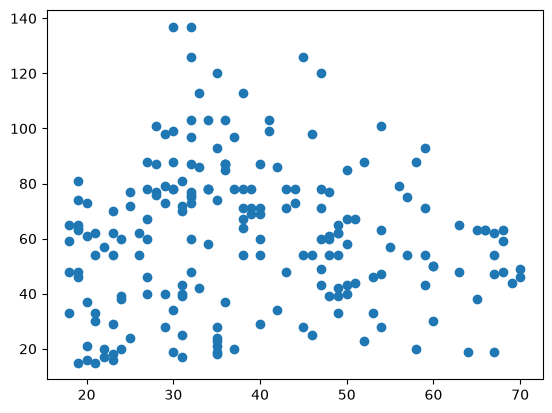

In [35]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.show()


import matplotlib.pyplot as plt digunakan untuk memanggil library Matplotlib yang digunakan untuk membuat grafik. plt.scatter(x, y) digunakan untuk membuat grafik scatter dengan x sebagai Annual Income dan y sebagai Spending Score, sehingga setiap pelanggan ditampilkan sebagai sebuah titik. Kemudian, plt.show() digunakan untuk menampilkan grafik tersebut agar kita bisa melihat pola atau persebaran data pelanggan sebelum dilakukan clustering.

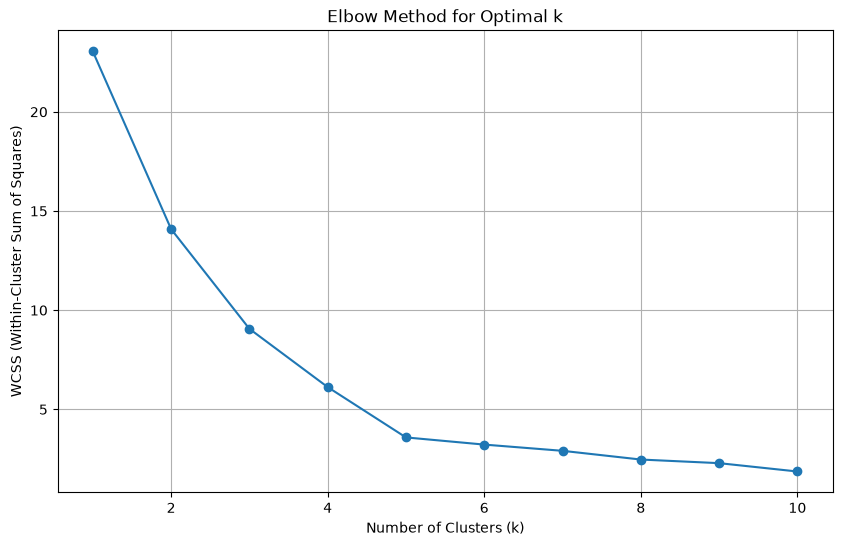

In [27]:

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
# Scaling data dengan MinMaxScaler
scaler = MinMaxScaler()
# Mengambil kolom X (index 3) dan Y (index 4) dari DataFrame
X = pd.DataFrame({'Annual Income (k$)': x, 'Spending Score (1-100)': y})
X_scaled = scaler.fit_transform(X)
# Menentukan jumlah klaster optimal menggunakan Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Membuat plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt digunakan untuk memanggil library Matplotlib untuk membuat grafik. from sklearn.cluster import KMeans digunakan untuk memanggil metode K-Means yang akan digunakan dalam proses clustering,  MinMaxScaler digunakan untuk menyamakan skala data agar nilai Annual Income dan Spending Score dapat diproses secara seimbang. scaler = MinMaxScaler() membuat objek untuk proses scaling, kemudian X = pd.DataFrame() digunakan untuk menggabungkan Annual Income dan Spending Score menjadi data yang akan digunakan dalam clustering. X_scaled = scaler.fit_transform(X) melakukan scaling pada data tersebut. Selanjutnya, wcss = [] digunakan untuk menyimpan nilai WCSS, lalu perulangan for i in range(1, 11) mencoba jumlah cluster dari 1 sampai 10. KMeans(n_clusters=i, random_state=42) membuat model K-Means sesuai jumlah cluster, kmeans.fit(X_scaled) menjalankan clustering, dan wcss.append(kmeans.inertia_) menyimpan nilai WCSS dari setiap cluster. Terakhir, bagian plt.figure() sampai plt.show() digunakan untuk membuat dan menampilkan grafik Elbow Method, sehingga kita dapat melihat titik siku pada grafik untuk menentukan jumlah cluster yang paling optimal.

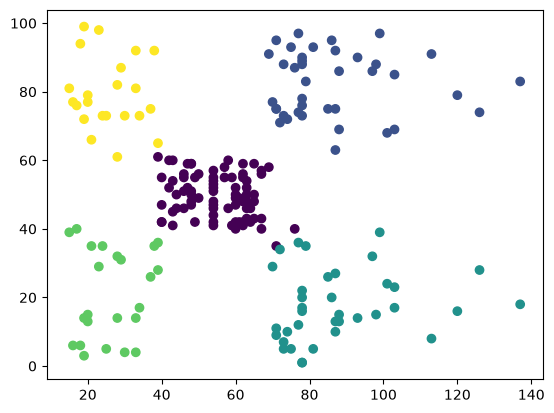

In [21]:
# dari elbow method, nilai k optimal untuk data ini adalah 5
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)
# Plot hasil klaster
plt.scatter(x, y, c=kmeans.labels_)
plt.show()

#dari elbow method, nilai k optimal untuk data ini adalah 5 digunakan sebagai komentar untuk menjelaskan bahwa berdasarkan grafik Elbow, jumlah cluster yang dipilih adalah 5. kmeans = KMeans(n_clusters=5) digunakan untuk membuat model K-Means dengan 5 cluster, kemudian kmeans.fit(X) digunakan untuk menjalankan proses clustering pada data X. Setelah itu, plt.scatter(x, y, c=kmeans.labels_) digunakan untuk menampilkan hasil clustering dalam bentuk scatter plot, dengan warna titik yang berbeda menunjukkan kelompok pelanggan yang berbeda. Terakhir, plt.show() digunakan untuk menampilkan grafik hasil clustering tersebut.

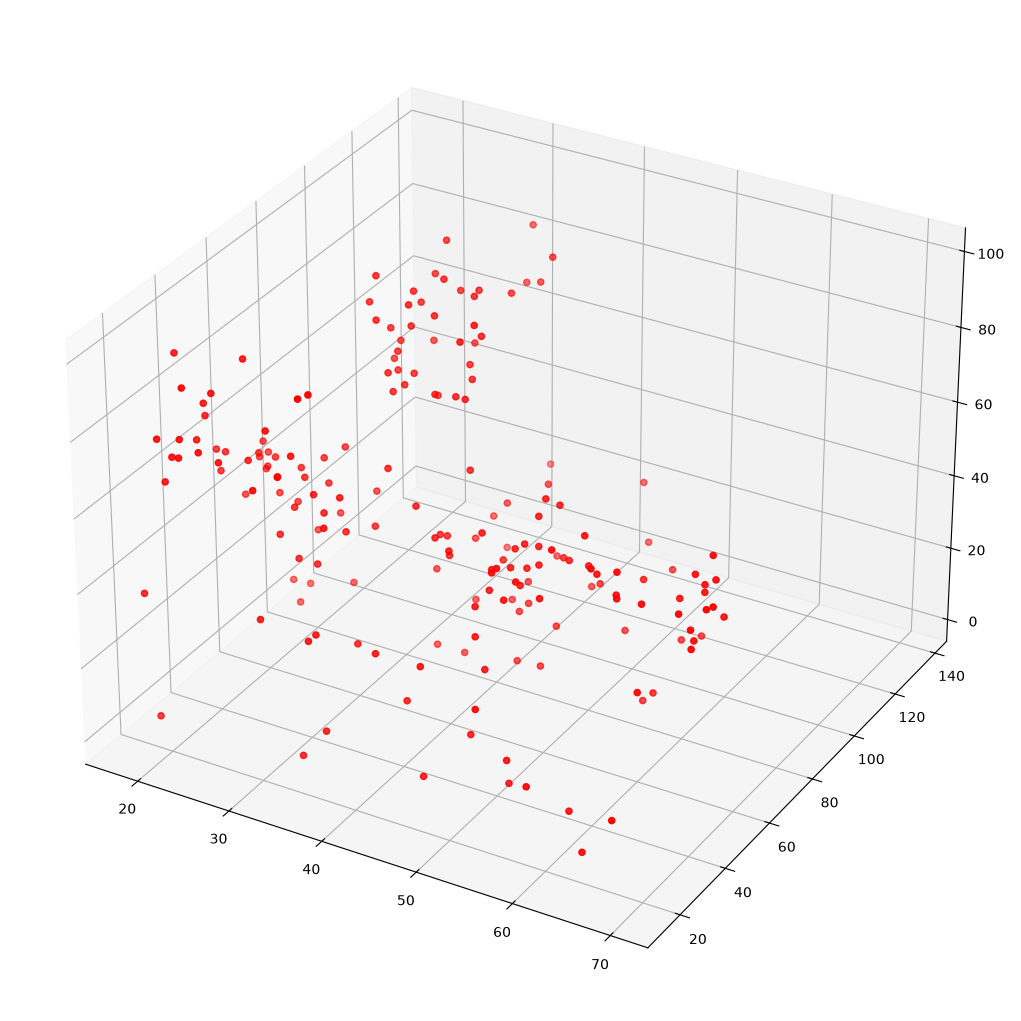

In [28]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
# Data Age, Annual Income, dan Spending Score
x = df.iloc[:, 2]
y = df.iloc[:, 3]
z = df.iloc[:, 4]
# Membuat plot 3D
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')
# Plot data
ax.scatter(x, y, z, c='red', marker='o')
# Label sumbu


from mpl_toolkits.mplot3d import Axes3D digunakan untuk mengaktifkan fitur grafik 3D pada Matplotlib, sedangkan import numpy as np digunakan untuk memanggil library NumPy yang membantu dalam pengolahan data berbentuk array. x = df.iloc[:, 2], y = df.iloc[:, 3], dan z = df.iloc[:, 4] digunakan untuk mengambil data Age, Annual Income, dan Spending Score dari dataset. Selanjutnya, fig dan ax digunakan untuk membuat area grafik 3D, kemudian ax.scatter(x, y, z, c='red', marker='o') digunakan untuk menampilkan setiap pelanggan sebagai titik dalam grafik 3D. Jadi, kode ini digunakan untuk melihat persebaran pelanggan berdasarkan tiga variabel sekaligus, yaitu umur, pendapatan, dan skor belanja.

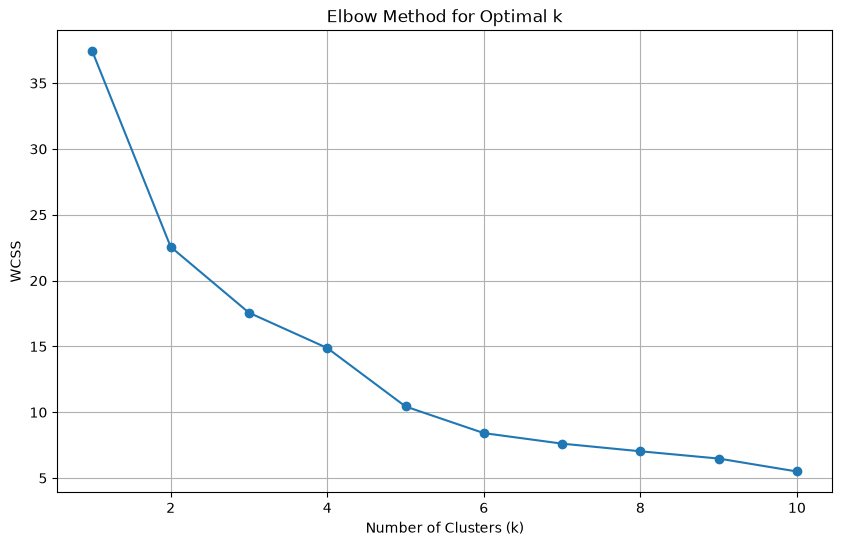

In [33]:

# Menggabungkan data X, Y, Z menjadi array untuk clustering
X = np.array(list(zip(x, y, z)))
# Scaling data dengan MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
# Menentukan jumlah klaster optimal dengan Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
# Visualisasi Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)

X = np.array(list(zip(x, y, z))) digunakan untuk menggabungkan data Age, Annual Income, dan Spending Score menjadi satu array yang akan digunakan dalam clustering. MinMaxScaler() digunakan untuk menyamakan skala ketiga variabel, kemudian fit_transform(X) melakukan proses scaling pada data. Selanjutnya, wcss = [] digunakan untuk menyimpan nilai WCSS, sedangkan perulangan for i in range(1, 11) mencoba jumlah cluster dari 1 sampai 10. Setiap model K-Means dilatih dengan kmeans.fit(X_scaled), kemudian nilai WCSS disimpan menggunakan kmeans.inertia_. Terakhir, plt.plot() digunakan untuk membuat grafik Elbow Method, yang nantinya digunakan untuk melihat titik siku dan menentukan jumlah cluster yang paling optimal.

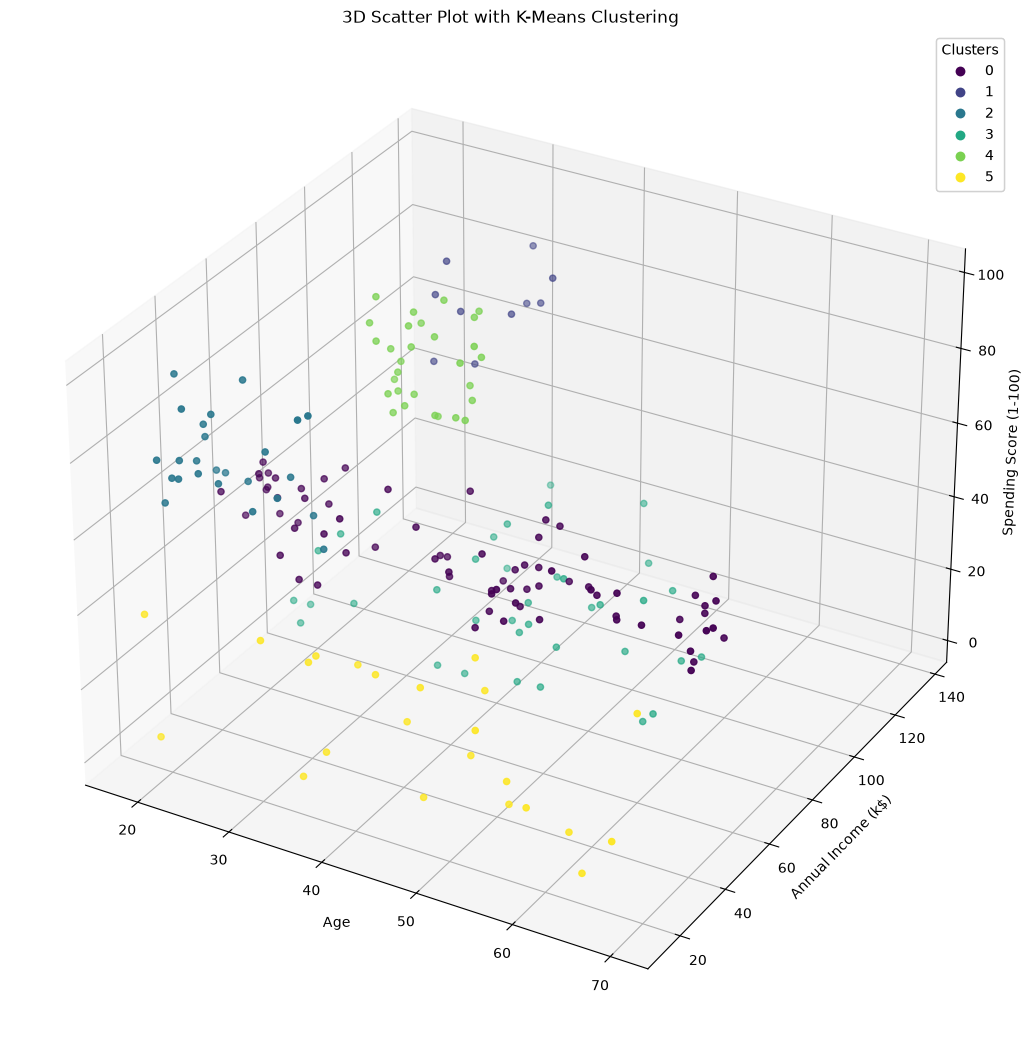

In [34]:
# Pilih k optimal setelah melihat Elbow
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X)
# Menambahkan hasil klaster ke DataFrame
df['Cluster'] = clusters
# Visualisasi 3D Hasil K-Means
# Plot data dengan warna berdasarkan klaster
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')
# Plot setiap titik dengan warna sesuai klaster
scatter = ax.scatter(x, y, z, c=clusters, cmap='viridis', marker='o')
# Label sumbu
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
# Menampilkan legenda klaster
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)
plt.title('3D Scatter Plot with K-Means Clustering')
plt.show()

kmeans = KMeans(n_clusters=6, random_state=42) digunakan untuk membuat model K-Means dengan 6 cluster berdasarkan hasil Elbow Method. clusters = kmeans.fit_predict(X) digunakan untuk menjalankan clustering sekaligus menentukan setiap pelanggan masuk ke cluster mana. Kemudian, df['Cluster'] = clusters digunakan untuk menambahkan hasil cluster ke dalam dataset. Setelah itu, bagian fig dan ax digunakan untuk membuat grafik 3D, sedangkan ax.scatter(x, y, z, c=clusters, ...) menampilkan data pelanggan dengan warna berbeda berdasarkan cluster masing-masing. set_xlabel(), set_ylabel(), dan set_zlabel() digunakan untuk memberi nama pada sumbu Age, Annual Income, dan Spending Score. Terakhir, legend_elements() digunakan untuk menampilkan legenda setiap cluster, sehingga hasil pengelompokan pelanggan dapat lebih mudah dilihat dan dipahami.